#### Putri Andani
### Pembuatan Dataset untuk model FNO (Fourier Neural Operator) ###
Dataset yang dibutuhkan berupa pasangan input $\psi_0$ dan output $\psi_t$, pembuatan dataset dilakukan dengan menyelesaiakan persamaan Schrodinger waktu imajiner dengan metode FDTD (Finite Difference Time Domain)

Untuk penyederhanaan, Persamaan Schrodinger waktu imajiner diubah ke persamaan tanpa dimensi terlebih dahulu dengan mengambil konstanta Planck tereduksi $\hbar$ dan massa partikel $m$ sama dengan 1
sehingga bentuk Persamaan Schrodinger waktu imajiner menjadi
$$\frac{\partial \psi(x, \tau)}{\partial \tau} = \left[\frac{1}{2} \nabla^2 - V(x)\right] \psi(x, \tau))$$

Selanjutnya, dengan menggunakan metode FDTD, persamaan di atas didiskretkan terhadap ruang dan waktu. Untuk itu, ruang dan waktu imajiner dibagi menjadi grid diskrit yang merepresentasikan posisi $x_i$ dan waktu $\tau_n$ , masing-masing dengan selisih $\Delta x$ dan $\Delta \tau$

###  Persamaan Diskritisasi Schrödinger Waktu Imajiner dengan FDTD

Dengan menggunakan metode FDTD, turunan pertama terhadap waktu pada ruas kiri Persamaan Schrödinger waktu imajiner dituliskan sebagai:

$$
\frac{\partial \psi(x,\tau)}{\partial \tau} \approx \frac{\psi^{n+1}(i) - \psi^n(i)}{\Delta \tau}
$$

Sedangkan turunan kedua terhadap ruang pada ruas kanan adalah:

$$
\frac{1}{2} \nabla^2 \psi(x,\tau) \approx \frac{1}{2(\Delta x)^2} \left[ \psi^n(i+1) - 2\psi^n(i) + \psi^n(i-1) \right]
$$

Untuk mempertahankan kestabilan numerik, efek potensial $V(i)$ disertakan dengan rata-rata $\psi$ pada waktu $n$ dan $n+1$, yaitu:

$$
V(i) \cdot \frac{ \psi^{n+1}(i) + \psi^n(i) }{2}
$$

Sehingga, bentuk diskrit dari Persamaan Schrödinger waktu imajiner menjadi:

$$
\frac{\psi^{n+1}(i) - \psi^n(i)}{\Delta \tau} = \frac{1}{2(\Delta x)^2} \left[ \psi^n(i+1) - 2\psi^n(i) + \psi^n(i-1) \right] - V(i) \cdot \frac{ \psi^{n+1}(i) + \psi^n(i) }{2}
$$


Persamaan di atas dapat disusun ulang menjadi bentuk eksplisit untuk $\psi^{n+1}(i)$:

$$
\psi^{n+1}(i) = \frac{ \left( 1 - \frac{\Delta \tau}{2} V(i) \right) \psi^n(i) + \Delta \tau \cdot \frac{1}{2(\Delta x)^2} \left( \psi^n(i+1) - 2\psi^n(i) + \psi^n(i-1) \right) }{1 + \frac{\Delta \tau}{2} V(i)}
$$

Atau dalam bentuk koefisien $\alpha(i)$ dan $\beta(i)$:

$$
\psi^{n+1}(i) = \alpha(i)\cdot \psi^n(i) + \beta(i) \cdot \left( \psi^n(i+1) - 2\psi^n(i) + \psi^n(i-1) \right)
$$

dengan:

$$
\alpha(i) = \frac{1 - \frac{1}{2} \Delta \tau \cdot V(i)}{1 + \frac{1}{2} \Delta \tau \cdot V(i)}, \quad
\beta(i) = \frac{ \Delta \tau }{2(\Delta x)^2 \left( 1 + \frac{1}{2} \Delta \tau \cdot V(i) \right) }
$$


Agar simulasi numerik stabil, disarankan menggunakan:

$$
\Delta \tau \leq (\Delta x)^2
$$


In [ ]:
# import pustaka
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os

In [ ]:
#inisialisasi Parameter
i = 0 #indeks ruang
n = 0 #indeks waktu
Nx = 100 #grid x
Nt = 100
dx = 0.5#delta x
dx2 = dx**2
dt = 0.5*dx2 #sesuai syarat stabilitas
L = Nx*dx

In [ ]:
import numpy as np

# Parameter grid
L = 1.0
x = np.linspace(0, L, Nx+1)

 # Potensial kotak (v)
v = np.zeros(Nx+1)
for i in range(Nx+1):
    if i <= 20:
        v[i] = 10.0
    elif i < 40:
        v[i] = 0.0
    else:
        v[i] = 10.0
potensial_all = np.tile(v, (5000, 1))  # duplikasi v jadi (5000, 101)


# Hitung koefisien a dan b
a = np.zeros(Nx+1)
b = np.zeros(Nx+1)
for i in range(Nx+1):
    a[i] = (1 - 0.5*dt*v[i])/(1 + 0.5*dt*v[i])
    b[i] = dt/(2*dx2*(1+0.5*v[i]))

In [ ]:
# Membuat folder penyimpanan Dataset
folder = "data_psi_potensial_kotak(10000_bener11)"
if not os.path.exists(folder):
    os.makedirs(folder)
else:
    for file in os.listdir(folder):
        os.remove(os.path.join(folder, file))

In [ ]:
# Array untuk menyimpan seluruh data psi awal dan akhir
psi_awal_all = []
psi_akhir_all = []

In [ ]:
# psi = fungsi gelombang ke-i pada waktu n
# psi_new = fungsi gelombang ke-i pada n+1
# psi input acak sebanyak 5000 kali
for data_ke in range(5000):
    #print("data ke:", data_ke)


    # Inisialisasi psi awal
    psi = np.zeros(Nx+1)
    psi_new = np.zeros(Nx+1)

    # Acak posisi awal psi
    random_index = np.random.randint(1, Nx)
    psi[random_index] = 10

    # Normalisasi awal
    sum_psi = np.sum(psi[1:Nx]**2)
    A = 1 / np.sqrt(sum_psi * dx)
    psi *= A

    # Simpan psi awal
    psi_awal = psi.copy()

    # Iterasi dengan FDTD
    for n in range(Nt):
        for i in range(1, Nx):
            psi_new[i] = a[i] * psi[i] + b[i] * (psi[i+1] - 2 * psi[i] + psi[i-1])
        psi[1:Nx] = psi_new[1:Nx]  # update untuk iterasi selanjutnya

    # Simpan data psi awal dan akhir
    psi_awal_all.append(psi_awal)
    psi_akhir_all.append(psi.copy())

In [ ]:
# Konversi ke array
psi_awal_all = np.array(psi_awal_all)   # shape (5000, Nx+1)
psi_akhir_all = np.array(psi_akhir_all) # shape (5000, Nx+1)

In [ ]:
# Simpan ke 1 file .npz
np.savez_compressed(f"{folder}/kotak11_bener.npz",
                    psi_awal=psi_awal_all,
                    psi_akhir=psi_akhir_all,
                    potensial= potensial_all)

<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_4191/94738326.py:2: SyntaxWarning: invalid escape sequence '\P'
  plt.plot(x, psi_awal_all[0], label='$\Psi$ Awal')
/tmp/ipykernel_4191/94738326.py:3: SyntaxWarning: invalid escape sequence '\P'
  plt.plot(x, 100*psi_akhir_all[0], label='$\Psi$ Akhir')
/tmp/ipykernel_4191/94738326.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\psi$')


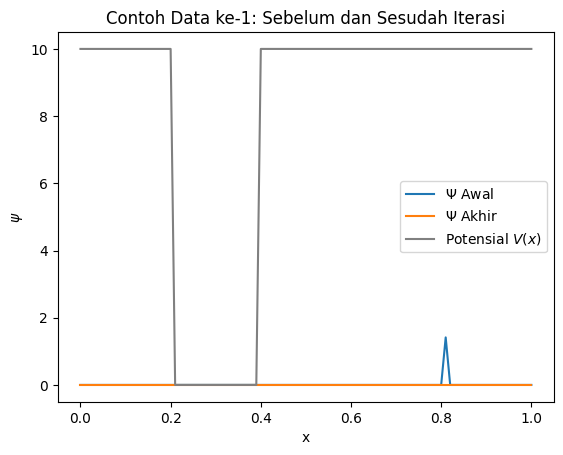

In [ ]:
# Visualisasi 1 sampel data
plt.plot(x, psi_awal_all[0], label='$\Psi$ Awal')
plt.plot(x, 100*psi_akhir_all[0], label='$\Psi$ Akhir')
plt.plot(x, v, label='Potensial $V(x)$', color='gray')
plt.xlabel('x')
plt.ylabel('$\psi$')
plt.legend()
plt.title("Contoh Data ke-1: Sebelum dan Sesudah Iterasi")
plt.show()